In [1]:
#  import libraries
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

In [8]:
# load dataset
df = pd.read_csv("/Users/sarfarazali/Downloads/sales_forcasting.csv")
df.head()


,date,store_id,product_id,promotion_active,holiday_flag,base_demand,weekly_seasonality_component,yearly_seasonality_component,sales
0,2022-01-01,1,1,0,0,122,-9.75,0.13,82
1,2022-01-02,1,1,0,0,122,-7.82,0.27,107
2,2022-01-03,1,1,1,1,122,0.00,0.40,203
3,2022-01-04,1,1,0,1,122,7.82,0.53,165
4,2022-01-05,1,1,0,0,122,9.75,0.67,149


In [9]:
df.shape


(146000, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146000 entries, 0 to 145999
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          146000 non-null  object 
 1   store_id                      146000 non-null  int64  
 2   product_id                    146000 non-null  int64  
 3   promotion_active              146000 non-null  int64  
 4   holiday_flag                  146000 non-null  int64  
 5   base_demand                   146000 non-null  int64  
 6   weekly_seasonality_component  146000 non-null  float64
 7   yearly_seasonality_component  146000 non-null  float64
 8   sales                         146000 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.0+ MB


In [11]:
df.describe()

,store_id,product_id,promotion_active,holiday_flag,base_demand,weekly_seasonality_component,yearly_seasonality_component,sales
count,146000.000000,146000.000000,146000.000000,146000.000000,146000.000000,146000.000000,1.460000e+05,146000.000000
mean,5.500000,10.500000,0.150705,0.050048,113.835000,-0.024068,-1.790957e-17,132.384767
std,2.872291,5.766301,0.357763,0.218045,50.991329,7.077511,9.642537e+00,57.802362
min,1.000000,1.000000,0.000000,0.000000,20.000000,-9.750000,-1.988000e+01,0.000000
25%,3.000000,5.750000,0.000000,0.000000,68.750000,-7.820000,-7.710000e+00,86.000000
50%,5.500000,10.500000,0.000000,0.000000,125.500000,0.000000,0.000000e+00,138.000000
75%,8.000000,15.250000,0.000000,0.000000,151.500000,7.820000,7.710000e+00,176.000000
max,10.000000,20.000000,1.000000,1.000000,197.000000,9.750000,1.988000e+01,372.000000


In [12]:
df.isnull().sum()

date                            0
store_id                        0
product_id                      0
promotion_active                0
holiday_flag                    0
base_demand                     0
weekly_seasonality_component    0
yearly_seasonality_component    0
sales                           0
dtype: int64

In [13]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["sales"] >= Q1 - 1.5*IQR) &
        (df["sales"] <= Q3 + 1.5*IQR)]

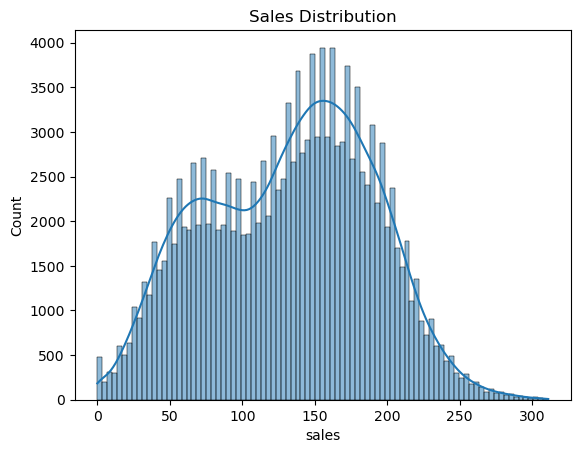

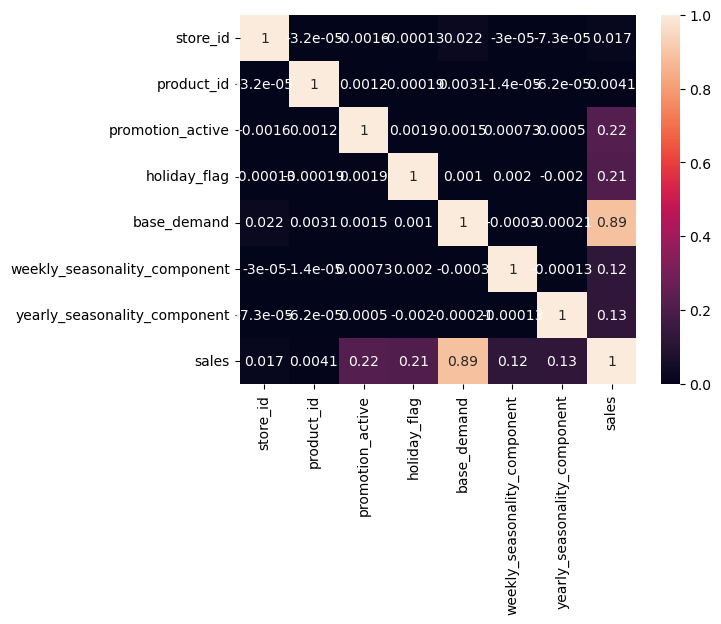

In [14]:
# Salary distribution
sns.histplot(df["sales"], kde=True)
plt.title("Sales Distribution")
plt.show()

# Correlation
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [18]:
# define features
df['log_base_demand'] = np.log1p(df['base_demand'])
df['sqrt_base_demand'] = np.sqrt(df['base_demand'])
df['promo_strength'] = df['promotion_active'] * df['base_demand']
df['holiday_strength'] = df['holiday_flag'] * df['base_demand']
df['seasonality_weighted'] = (
    df['weekly_seasonality_component'] * 0.7 +
    df['yearly_seasonality_component'] * 1.3
)
df['seasonality_demand'] = df['seasonality_weighted'] * df['base_demand']
df['promo_seasonality'] = (
    df['promotion_active'] * df['weekly_seasonality_component']
)
df['holiday_seasonality'] = (
    df['holiday_flag'] * df['yearly_seasonality_component']
)
store_avg = df.groupby('store_id')['sales'].mean()
df['store_avg_sales'] = df['store_id'].map(store_avg)
product_avg = df.groupby('product_id')['sales'].mean()
df['product_avg_sales'] = df['product_id'].map(product_avg)
df['seasonality_ratio'] = (
    df['weekly_seasonality_component'] /
    (df['yearly_seasonality_component'] + 1e-5)
)
df['promo_ratio'] = df['promotion_active'] / (df['base_demand'] + 1)
df['final_demand_signal'] = (
    df['base_demand']
    + df['promo_strength']
    + df['holiday_strength']
    + df['seasonality_demand']
)

In [19]:
df = df.drop([
    'weekly_seasonality_component',
    'yearly_seasonality_component'
], axis=1)

In [20]:
# Define x & y
X = df.drop(["sales"], axis=1)
Y = np.log1p(df["sales"])

In [21]:
#  Define numerical and categorical features
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Define transformers
num_transformer = StandardScaler()  
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [22]:
# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Display the shape of the data
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (116768, 19)
Testing set shape: (29192, 19)


In [23]:
# Define the pipeline
pipe = Pipeline([
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# Train the model
pipe.fit(X_train, Y_train)

,steps,"[('pre', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
# Make predictions
Y_pred_log = pipe.predict(X_test)
Y_pred = np.expm1(Y_pred_log)
Y_test_actual = np.expm1(Y_test)

In [25]:
# Evaluation
r2 = r2_score(Y_test_actual, Y_pred)
print("R2:", r2)

mae = mean_absolute_error(Y_test_actual, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test_actual, Y_pred))


print("MAE:", mae)
print("RMSE:", rmse)


R2: 0.8993241559510113
MAE: 14.496676275005068
RMSE: 18.33164681471844


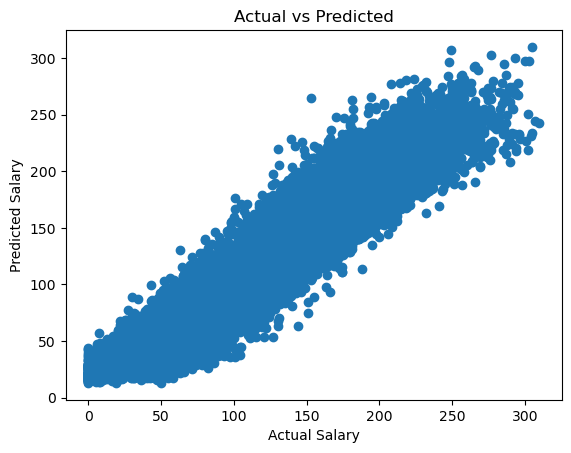

In [26]:
# ACTUAL vs PREDICTED GRAPH
plt.figure()
plt.scatter(Y_test_actual, Y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [27]:
# FEATURE IMPORTANCE
model = pipe.named_steps["lr"]
feature_names = pipe.named_steps["pre"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_
})

coef_df["impact_%"] = (np.exp(coef_df["coef"]) - 1) * 100

coef_df = coef_df.sort_values(by="coef", ascending=False)
coef_df.head(10)

,feature,coef,impact_%
5,num__log_base_demand,0.564457,75.849311
9,num__seasonality_weighted,0.265561,30.416247
3,num__holiday_flag,0.192959,21.283321
693,cat__date_2023-11-07,0.183542,20.146555
658,cat__date_2023-10-03,0.176099,19.255578
694,cat__date_2023-11-08,0.175650,19.202049
708,cat__date_2023-11-22,0.166772,18.148519
659,cat__date_2023-10-04,0.166519,18.118651
715,cat__date_2023-11-29,0.165106,17.951760
728,cat__date_2023-12-12,0.164854,17.922100
